# **Final Model**

*Same architecture and cleaning like my improved model, but with the most recent datasets I have*

In [1]:
import os
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pickle

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

import sys
sys.path.insert(0, '../..')

from modeling.dataset import CarPriceDataset
from modeling.model import MLPCarPriceRegressionNet_V1, MLPCarPriceRegressionNet_V2
from modeling.train import train_model
from modeling.test import test_model
from modeling.plots_and_metrics import train_plot, train_metrics, test_plot, test_metrics, test_show_extreme_cases
from modeling.plots_and_metrics import plot_outlier_years, plot_outlier_km, plot_outlier_price, plot_outlier_by_manufacturer, plot_outlier_by_kw

from preprocessing.preprocess import PreProcessor
from preprocessing.clean import Cleaner
from preprocessing.impute import Imputer
from preprocessing.engineer import Engineer 

## **Cleaning & Imputing**

*With latest datasets, focusing on the range 2M - 50M like in the improved model*

In [2]:
FILENAME = 'car_details_155998_20250907.csv'

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

df = pd.read_csv(f'../../data/raw/{FILENAME}')

cleaner = Cleaner(price_lower=2_000_000, price_upper = 50_000_000, year_lower = 2010, year_upper = None)
imputer = Imputer()
engineer = Engineer()

df = cleaner.clean(df)
summary = cleaner.get_summary()
display(summary)

df = imputer.impute(df)
summary = imputer.get_summary()
display(summary)

df = engineer.transform(df)
summary = engineer.get_summary()
display(summary)

df.to_csv(f'../../data/clean/{FILENAME}', index=False)

,Feature,Length Before,Length After,Dropped
0,Price,155998,107698,48300
1,Year,107698,97073,10625
2,Manufacturer/Model,97073,96956,117
3,Kilometers,96956,96936,20
4,Fuel Type,96936,96936,0
5,KW/LE,96936,95867,1069
6,Condition,95867,95867,0
7,Trunk Capacity,95867,95863,4
8,Body Type,95863,95862,1
9,Seats,95862,95860,2


,Feature,Missing Before,Missing After,Imputed
0,Kilometers,2041,0,2041
1,Fuel Type,862,0,862
2,Trunk Capacity,8639,0,8639
3,Seats,1025,0,1025
4,Color,17922,0,17922
5,Engine Capacity,342,0,342
6,Drive Type,1836,0,1836
7,Transmission Type,4674,0,4674
8,Number of Gears,23529,0,23529


,Feature,Unqiue Before,Unqiue After
0,Fuel Type,12,7
1,Transmission Type,9,6
2,Color,76,38


## **Data Prep**

- Model setup, architecture unchanged

- Scaling & Encoding unchanged 

- Splitting involves only putting active listings in the test dataset
    - Still not optimal in a sense that ideally I want to predict all of the active listings but I still do not have enough data for that 

In [3]:
MODEL_NAME = 'market_model'

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
car_data = pd.read_csv('../../data/raw/car_data_155998_20250907.csv')
active_ids = car_data[car_data['active'] == True]['id'].values

df_active = df[df['id'].isin(active_ids)]
df_inactive = df[~df['id'].isin(active_ids)]

test_size = int(len(df) * 0.1)
df_test = df_active.sample(n=min(test_size, len(df_active)), random_state=12)

df_remaining = df[~df['id'].isin(df_test['id'])]
df_train, df_val = train_test_split(df_remaining, test_size=0.111, random_state=12)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

df_test.to_csv(f'../../workspace/test_datasets/{FILENAME}', index=False)

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


preprocessor = PreProcessor()
preprocessor.fit(df_train)
preprocessor.save(f'../../workspace/config/{MODEL_NAME}.pkl', f'../../workspace/config/{MODEL_NAME}.json')

model = MLPCarPriceRegressionNet_V2(f'../../workspace/config/{MODEL_NAME}.pkl')

X_num_train, X_cat_train, y_train = preprocessor.transform(df_train, is_training = True, include_target = True)
X_num_val, X_cat_val, y_val = preprocessor.transform(df_val, is_training = False, include_target = True)
X_num_test, X_cat_test, y_test = preprocessor.transform(df_test, is_training = False, include_target = True)

train_dataset = CarPriceDataset(X_num_train, X_cat_train, y_train)
val_dataset = CarPriceDataset(X_num_val, X_cat_val, y_val)
test_dataset = CarPriceDataset(X_num_test, X_cat_test, y_test)

batch_size = 64

dataloader_train = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True)
dataloader_val = DataLoader(dataset = val_dataset, batch_size = batch_size, shuffle = True)
dataloader_test = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)


## **Training & Plotting training**

*Unchanged*

Training on: cpu

Epoch [1/150] (LR: 0.000500)
  Train Loss: 6.3682
  Val Loss:   0.1346
  Val MAPE:   31.62%

Epoch [2/150] (LR: 0.000500)
  Train Loss: 0.6815
  Val Loss:   0.1115
  Val MAPE:   23.00%

Epoch [3/150] (LR: 0.000500)
  Train Loss: 0.4396
  Val Loss:   0.0695
  Val MAPE:   20.28%

Epoch [4/150] (LR: 0.000500)
  Train Loss: 0.2607
  Val Loss:   0.1049
  Val MAPE:   33.08%
  Early stopping counter: 1/40

Epoch [5/150] (LR: 0.000500)
  Train Loss: 0.1728
  Val Loss:   0.0504
  Val MAPE:   19.13%

Epoch [6/150] (LR: 0.000500)
  Train Loss: 0.1102
  Val Loss:   0.0449
  Val MAPE:   14.82%

Epoch [7/150] (LR: 0.000500)
  Train Loss: 0.0706
  Val Loss:   0.0303
  Val MAPE:   13.30%

Epoch [8/150] (LR: 0.000500)
  Train Loss: 0.0505
  Val Loss:   0.0308
  Val MAPE:   12.60%
  Early stopping counter: 1/40

Epoch [9/150] (LR: 0.000500)
  Train Loss: 0.0394
  Val Loss:   0.0258
  Val MAPE:   12.00%

Epoch [10/150] (LR: 0.000500)
  Train Loss: 0.0357
  Val Loss:   0.0295
  Val MAPE:

Metric,Value
BEST EPOCH,91.000000
BEST VAL LOSS,0.019143


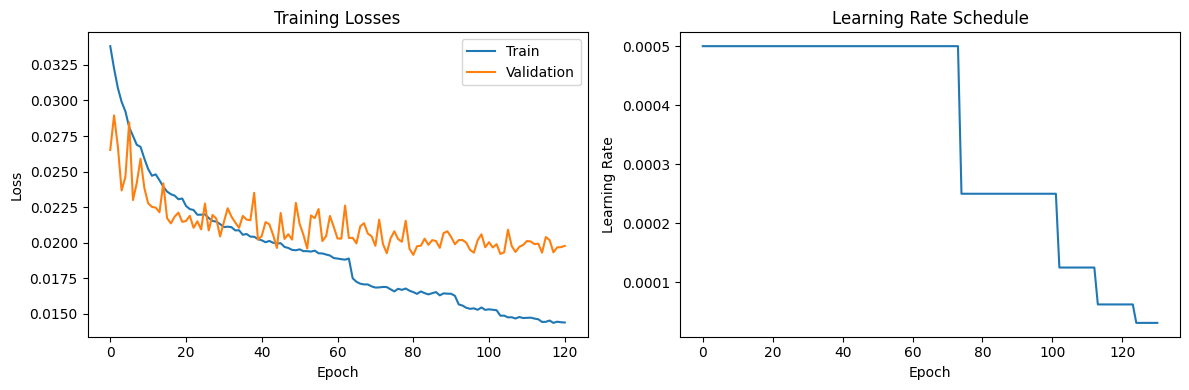

In [4]:
train = False

if train == True:
    history, model = train_model(
        model=model,
        train_loader=dataloader_train,
        val_loader=dataloader_val,
        epochs=150,
        learning_rate=0.0005,
        learning_rate_decay_factor=0.5
    )
    with open(f'../../workspace/train_histories/{MODEL_NAME}.pkl', 'wb') as f:
        pickle.dump(history, f)
    torch.save(model.state_dict(), f'../../workspace/models/{MODEL_NAME}.pt')

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

with open(f'../../workspace/train_histories/{MODEL_NAME}.pkl', 'rb') as f:
    history = pickle.load(f)

display(train_metrics(history=history).style.hide(axis=0))
train_plot(history=history, skip_first_x = 10)

## **Testing & Plotting**

*Unchanged*

**Plan:**

    - Displaying the most undervalued cars in another clean Notebook: evalute_market_model

Metric,Value,Description
MAE,1.09M Ft,Average absolute error
RMSE,2.01M Ft,Root mean squared error ~ penalizes outliers more
Mean APE,11.15%,Mean absolute percentage error ~ %
Median APE,8.40%,Median absolute percentage error ~ %
Within 10%,56.98%,Predictions with < 10% error
Within 20%,84.48%,Predictions with < 20% error
Within 30%,94.70%,Predictions with < 30% error


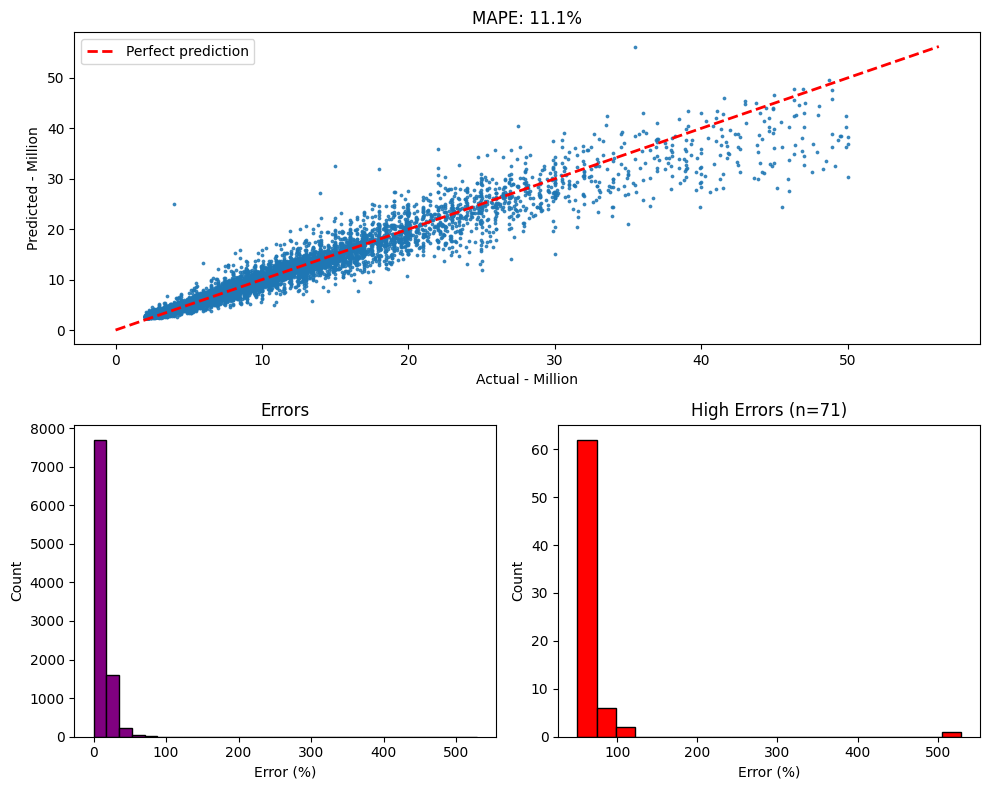

,price,predicted_price,percent_error,manufacturer,model,year,kw,kilometers
3703,3990000.0,25091272.0,528.854126,AUDI,Q7,2022.50,250.0,99000.0
5929,5999999.0,13287929.0,121.465469,PEUGEOT,208,2021.83,100.0,43300.0
6168,14999999.0,32569636.0,117.130753,PORSCHE,PANAMERA,2016.42,228.0,52050.0
6751,13995000.0,27250556.0,94.716469,MERCEDES-BENZ,GLC-OSZTÁLY GLC 350,2019.42,190.0,142331.0
362,3490000.0,6679608.0,91.392792,INFINITI,QX QX70,2017.08,175.0,210000.0
4598,8190000.0,15314074.0,86.985031,OPEL,MOKKA,2023.42,100.0,7200.0
3857,8490000.0,15826405.0,86.412247,RENAULT,CAPTUR,2024.67,116.0,5692.0
8111,2490000.0,4491765.5,80.392189,BMW,3-AS SOROZAT 325,2012.33,160.0,271324.0


In [5]:
model.load_state_dict(torch.load(f'../../workspace/models/{MODEL_NAME}.pt'))

results = test_model(model, dataloader_test)
''' results = {
        'actual_prices' : actual_prices,
        'prediction_prices' : pred_prices,
        'percent_errors' : percent_errors,
        'metrics' : {
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'median_ape': median_ape,
            'within_10': within_10,
            'within_20': within_20,
            'within_30': within_30
        }
    }
'''
display(test_metrics(results = results).style.hide(axis=0))
test_plot(results = results)

with pd.option_context('display.max_colwidth', None):
    display(test_show_extreme_cases(results = results, df_test = df_test,extreme_threshhold=80))


## **Outlier searching**

*Unchanged*

**Plan:**

- If I look at Outliers with a 30% threshhold rather than a 50% its clear that my model can't really predict cars with a lot of km (300k+) on them
    - Possibly introduce another km^2 scared feature or similar
- Same with KW



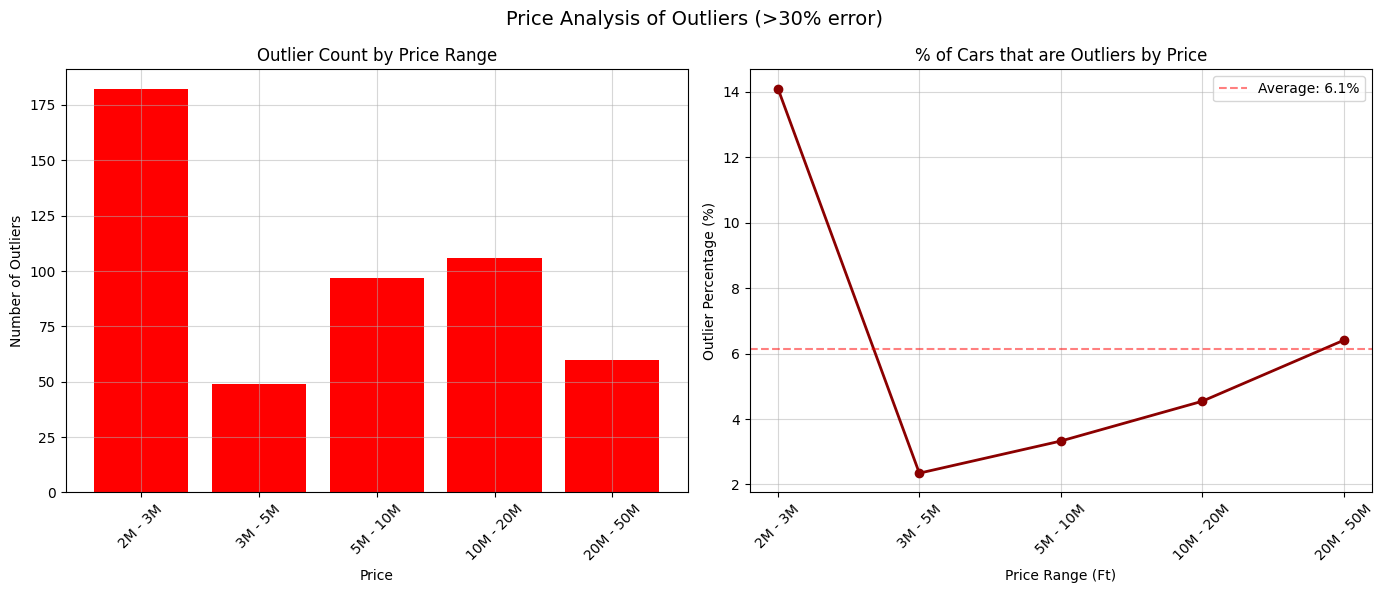

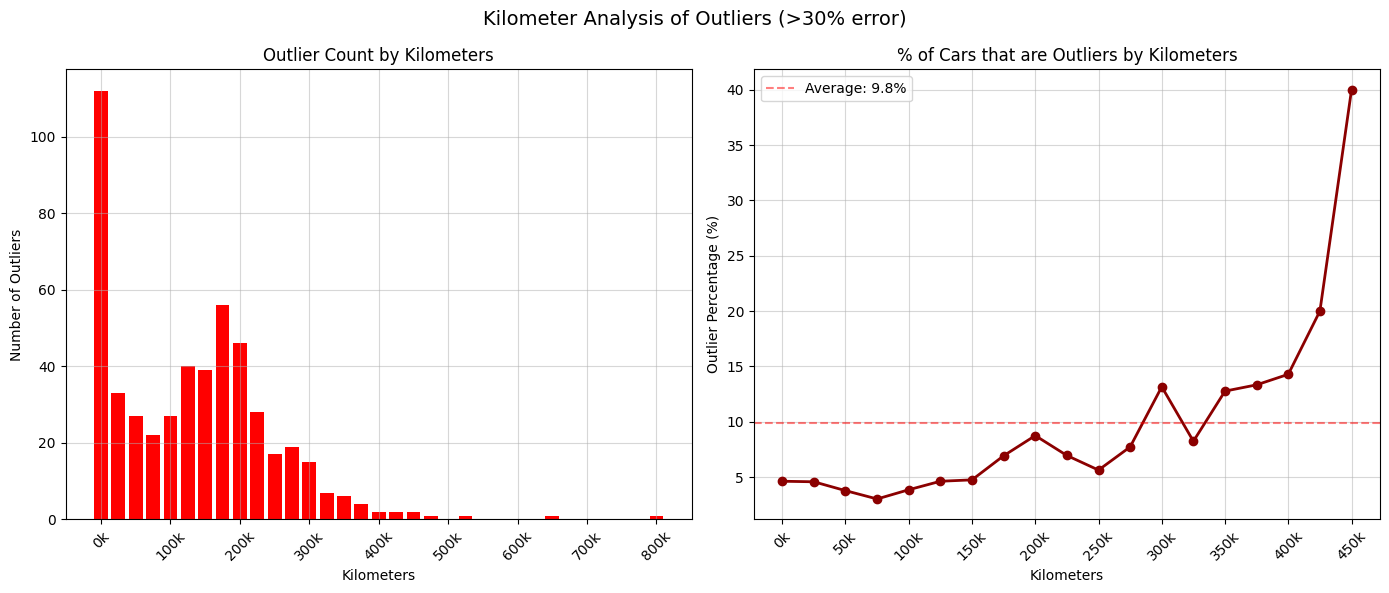

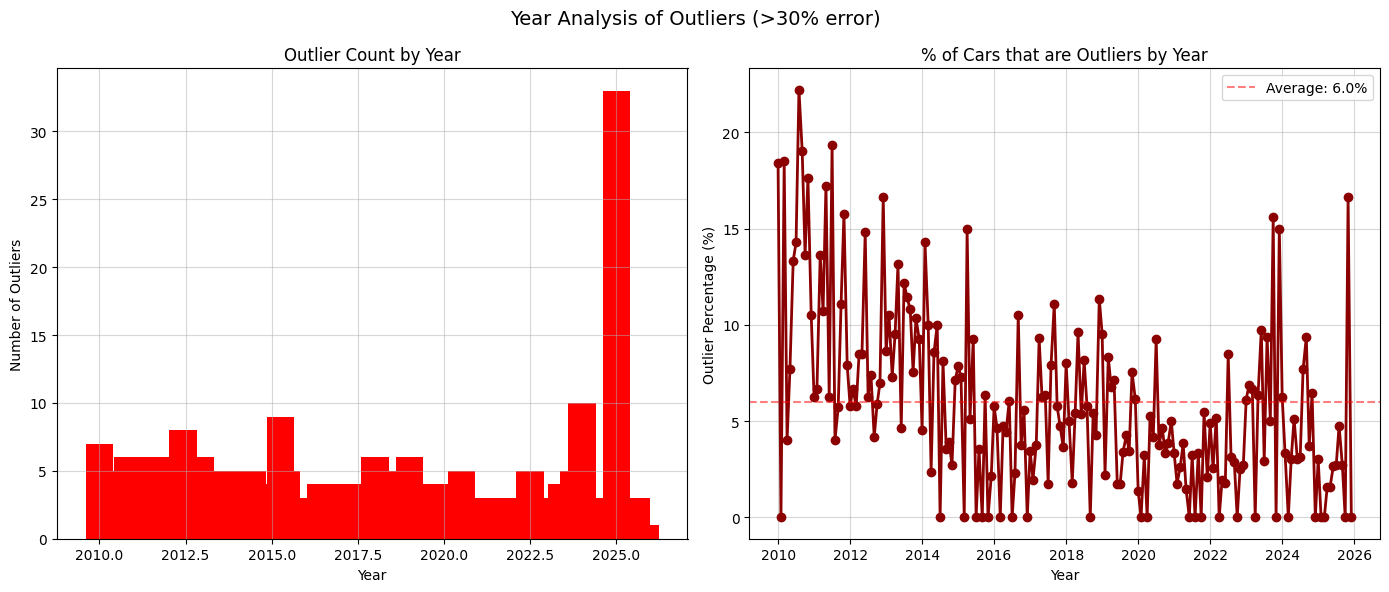

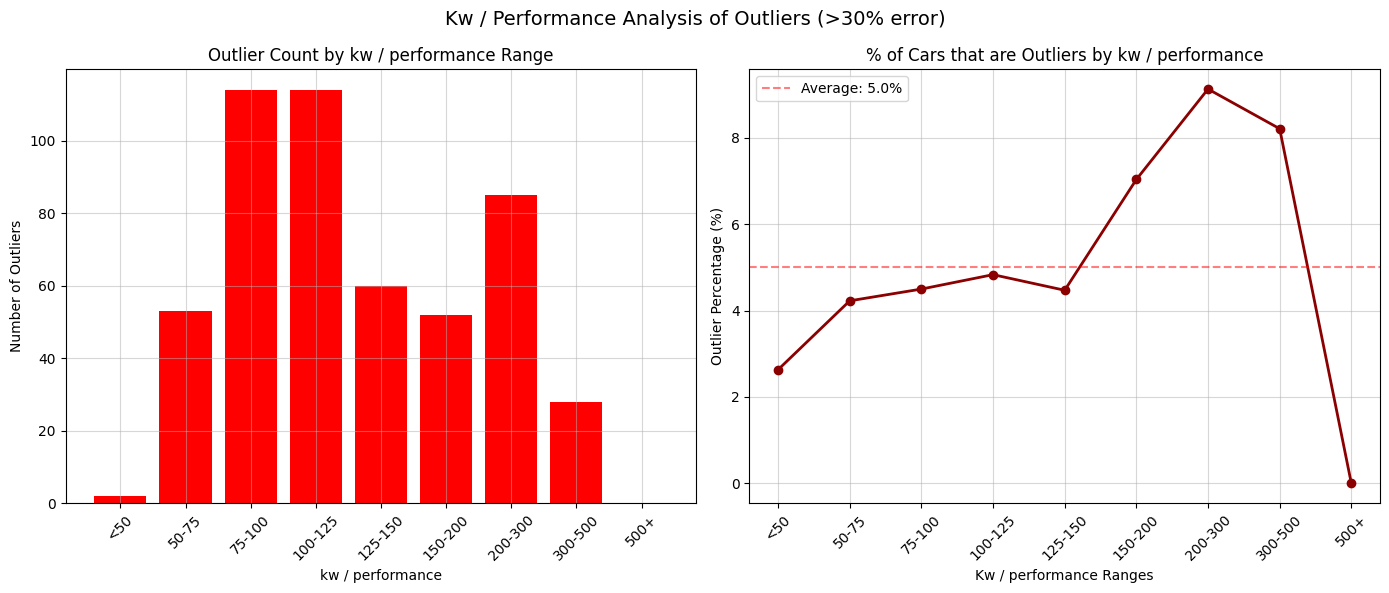

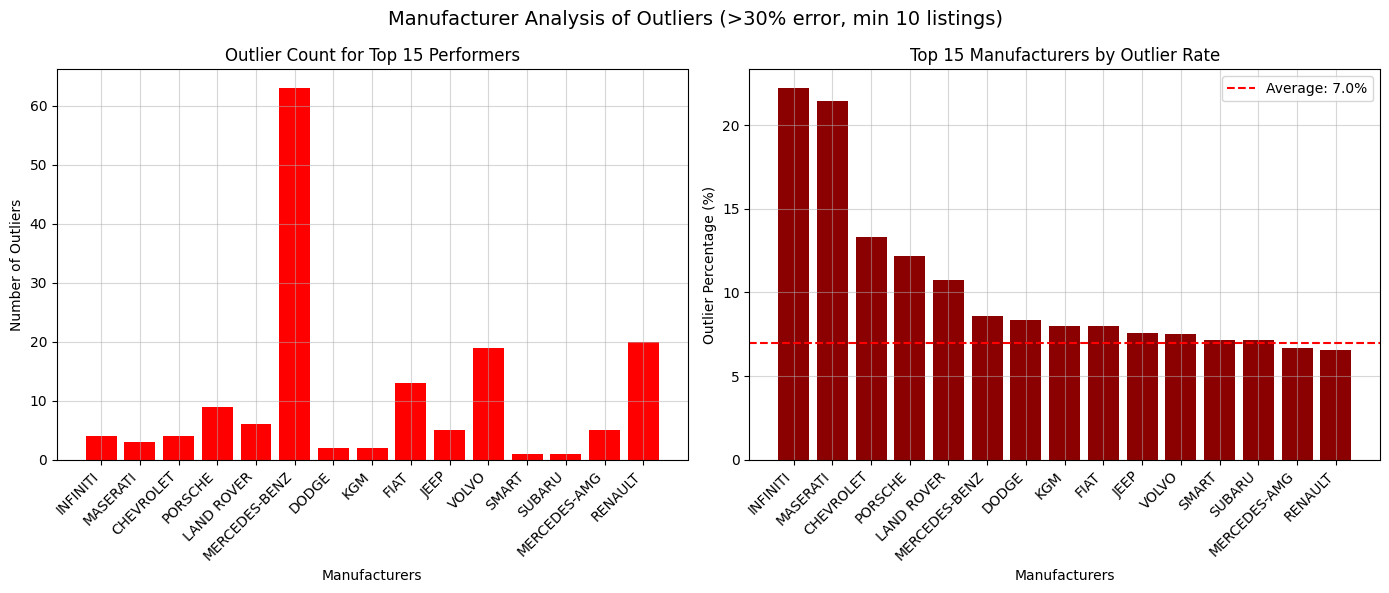

In [8]:
plot_outlier_price(results = results, df_test = df_test, threshold = 30, price_range='2M - 50M')
plot_outlier_km(results = results, df_test = df_test, threshold = 30)
plot_outlier_years(results = results, df_test = df_test, threshold = 30)
plot_outlier_by_kw(results = results, df_test = df_test, threshold = 30)
plot_outlier_by_manufacturer(results = results, df_test = df_test, threshold = 30, min_listings = 10)